In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("../raw_csv")

HTL_LIST = ["MeO2PACz", "NiOx", "PEDOT", "polyTPD", "PTAA"]

def infer_htl_from_path(p: Path):
    # Search folder names (and the filename) for a known HTL keyword
    for part in p.parts[::-1]:
        for h in HTL_LIST:
            if h.lower() in part.lower():
                return h
    return None

all_curves = []

for path in BASE.rglob("*.csv"):
    name = path.name.lower()

    # Only the reverse-scan files you want
    if ("au" not in name) or ("scan" not in name) or ("20v" not in name):
        continue

    htl = infer_htl_from_path(path)
    if htl is None:
        print("Skipping (can't infer HTL):", path)
        continue

    print("Loading:", path, "| HTL:", htl)

    df = pd.read_csv(path)

    # Normalize column names
    df.columns = [c.lower().strip() for c in df.columns]

    # Your files show: "voltage" and "Current" (case varies) -> after lowering: "voltage", "current"
    if ("voltage" not in df.columns) or ("current" not in df.columns):
        print("  ❌ Skipping (missing voltage/current). Columns:", df.columns.tolist())
        continue

    df["voltage"] = pd.to_numeric(df["voltage"], errors="coerce")
    df["current"] = pd.to_numeric(df["current"], errors="coerce")
    df = df.dropna(subset=["voltage", "current"])

    df["HTL"] = htl
    df["Electrode"] = "Au"
    df["SourceFile"] = str(path)   # full path so it's unique

    all_curves.append(df)

curves = pd.concat(all_curves, ignore_index=True) if all_curves else pd.DataFrame()
print("Total rows loaded:", len(curves))
curves.head()

Loading: ..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan_20V.csv | HTL: MeO2PACz
Loading: ..\raw_csv\type3_breakdown_Au\NiOx_Au_scan_20V.csv | HTL: NiOx
Loading: ..\raw_csv\type3_breakdown_Au\PEDOT_Au_scan_20V.csv | HTL: PEDOT
Loading: ..\raw_csv\type3_breakdown_Au\PolyTPD_Au_scan_20V.csv | HTL: polyTPD
Loading: ..\raw_csv\type3_breakdown_Au\PTAA_Au_scan_20V.csv | HTL: PTAA
Total rows loaded: 5005


,voltage,current,HTL,Electrode,SourceFile
0,2.0005,-881.885325,MeO2PACz,Au,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...
1,1.9805,-858.486622,MeO2PACz,Au,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...
2,1.9605,-835.149741,MeO2PACz,Au,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...
3,1.9405,-811.799930,MeO2PACz,Au,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...
4,1.9205,-788.489587,MeO2PACz,Au,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...


In [18]:
curves["HTL"].value_counts()

HTL
MeO2PACz    1101
NiOx        1101
polyTPD     1101
PTAA        1101
PEDOT        601
Name: count, dtype: int64

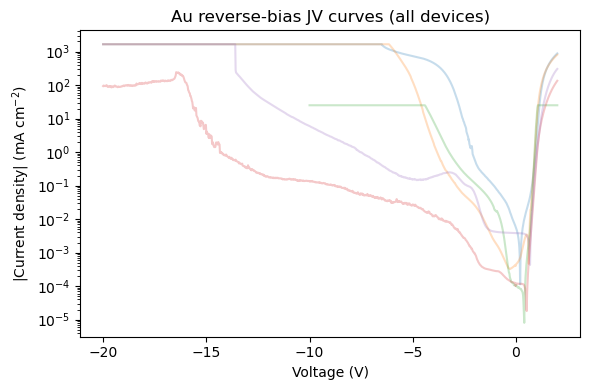

In [19]:
plt.figure(figsize=(6,4))

for (htl, src), g in curves.groupby(["HTL", "SourceFile"]):
    g = g.sort_values("voltage")

    V = g["voltage"].to_numpy()
    J = g["current"].to_numpy()

    # Use absolute current density for log scale
    J = np.abs(J)

    plt.plot(V, J, alpha=0.25, label=htl)

plt.yscale("log")
plt.xlabel("Voltage (V)")
plt.ylabel("|Current density| (mA cm$^{-2}$)")
plt.title("Au reverse-bias JV curves (all devices)")
plt.tight_layout()
plt.show()

In [20]:
import numpy as np

def extract_vbr_at_J_crossing(df, J_target=20.0):
    g = df.copy()
    g = g[g["voltage"] < 0]                # reverse only
    g = g.sort_values("voltage", ascending=False)  # 0 -> -20 (correct direction)

    V = g["voltage"].to_numpy()
    J = np.abs(g["current"].to_numpy())    # mA/cm2

    # need a below->above crossing as V becomes more negative
    for i in range(1, len(J)):
        if J[i-1] < J_target and J[i] >= J_target:
            # linear interpolation for better Vbr
            V0, V1 = V[i-1], V[i]
            J0, J1 = J[i-1], J[i]
            if J1 == J0:
                return V1
            return V0 + (J_target - J0) * (V1 - V0) / (J1 - J0)

    return np.nan

In [21]:
rows = []
for (htl, src), g in curves.groupby(["HTL","SourceFile"]):
    rows.append({
        "HTL": htl,
        "SourceFile": src,
        "Vbr_knee": extract_vbr_knee(g),
        "Vbr_20mA": extract_vbr_at_J_crossing(g, 20.0)
    })

pd.DataFrame(rows)

,HTL,SourceFile,Vbr_knee,Vbr_20mA
0,MeO2PACz,..\raw_csv\type3_breakdown_Au\MeO2PACz_Au_scan...,-3.6395,-2.720382
1,NiOx,..\raw_csv\type3_breakdown_Au\NiOx_Au_scan_20V...,-5.2995,-4.538829
2,PEDOT,..\raw_csv\type3_breakdown_Au\PEDOT_Au_scan_20...,-10.0000,-4.320927
3,PTAA,..\raw_csv\type3_breakdown_Au\PTAA_Au_scan_20V...,-20.0000,-15.498514
4,polyTPD,..\raw_csv\type3_breakdown_Au\PolyTPD_Au_scan_...,-13.5000,-11.542340


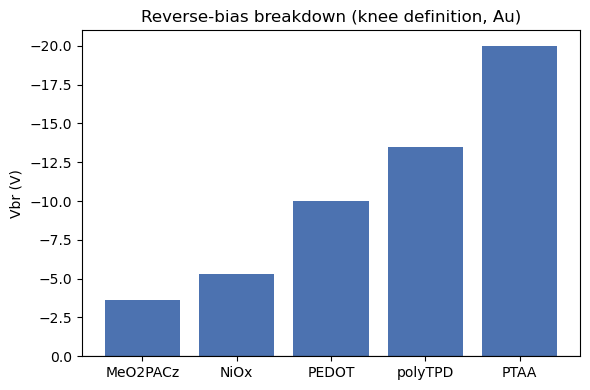

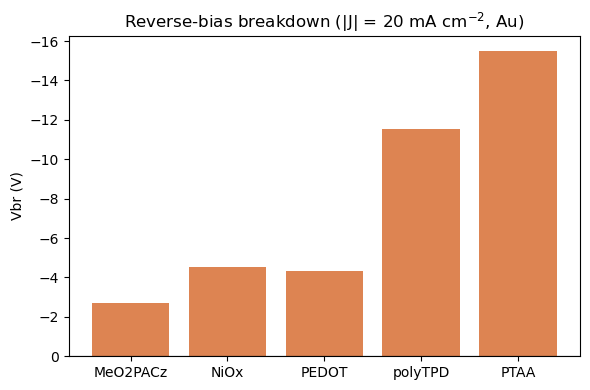

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Recreate DataFrame from your rows list
rows_df = pd.DataFrame(rows)

# Order HTLs as in paper
order = ["MeO2PACz", "NiOx", "PEDOT", "polyTPD", "PTAA"]
rows_df["HTL"] = pd.Categorical(rows_df["HTL"], categories=order, ordered=True)
rows_df = rows_df.sort_values("HTL")

# -----------------------------
# Plot 1 — Knee-based Vbr
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_knee"], color="#4C72B0")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (knee definition, Au)")
plt.gca().invert_yaxis()   # make more negative appear higher
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2 — 20 mA-based Vbr
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_20mA"], color="#DD8452")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Vbr (V)")
plt.title("Reverse-bias breakdown (|J| = 20 mA cm$^{-2}$, Au)")
plt.gca().invert_yaxis()   # make more negative appear higher
plt.tight_layout()
plt.show()

In [24]:
import os

# Create folders if they don't exist
os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# Save tables
rows_df = pd.DataFrame(rows)
rows_df.to_csv("../results/vbr_Au_all.csv", index=False)

summary_df = rows_df.groupby("HTL")[["Vbr_knee","Vbr_20mA"]].mean().reset_index()
summary_df.to_csv("../results/vbr_Au_summary.csv", index=False)

# Save figures (re-run plots just before this if needed)
plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_knee"])
plt.gca().invert_yaxis()
plt.savefig("../figures/Vbr_knee_Au.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6,4))
plt.bar(rows_df["HTL"], rows_df["Vbr_20mA"])
plt.gca().invert_yaxis()
plt.savefig("../figures/Vbr_20mA_Au.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved files:")
print("  ../results/vbr_Au_all.csv")
print("  ../results/vbr_Au_summary.csv")
print("  ../figures/Vbr_knee_Au.png")
print("  ../figures/Vbr_20mA_Au.png")

Saved files:
  ../results/vbr_Au_all.csv
  ../results/vbr_Au_summary.csv
  ../figures/Vbr_knee_Au.png
  ../figures/Vbr_20mA_Au.png


In [25]:
import json
import os

os.makedirs("../results", exist_ok=True)

# 1️⃣ Save cleaned Au JV curves
curves.to_csv("../results/Au_curves_cleaned.csv", index=False)

# 2️⃣ Save extraction parameters
params = {
    "extract_vbr_knee": {
        "vmin": -0.2,
        "baseline_window": [-1.2, -0.4],
        "slope_factor": 5,
        "max_logJ": 2.5
    },
    "extract_vbr_20mA": {
        "J_target": 20.0,
        "definition": "crossing from below to above as V decreases"
    }
}

with open("../results/Au_extraction_parameters.json", "w") as f:
    json.dump(params, f, indent=2)

# 3️⃣ Save a small README describing files
readme_text = """Au reverse-bias analysis outputs

Files:
- Au_curves_cleaned.csv : cleaned JV curves used for analysis
- vbr_Au_all.csv        : per-device Vbr values
- vbr_Au_summary.csv    : per-HTL average Vbr values
- Vbr_knee_Au.png       : bar plot using knee definition
- Vbr_20mA_Au.png       : bar plot using 20 mA definition
- Au_extraction_parameters.json : parameters used for Vbr extraction

Definitions:
- Vbr_knee : knee point where slope of log(|J|) increases sharply
- Vbr_20mA : voltage where |J| crosses 20 mA/cm^2 from below
"""

with open("../results/README_Au.txt", "w") as f:
    f.write(readme_text)

print("Additional files saved:")
print("  ../results/Au_curves_cleaned.csv")
print("  ../results/Au_extraction_parameters.json")
print("  ../results/README_Au.txt")

Additional files saved:
  ../results/Au_curves_cleaned.csv
  ../results/Au_extraction_parameters.json
  ../results/README_Au.txt
